___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Q-Learning Example on Frozen Lake (Discrete Actions)


--------
--------


# IMPORTANT NOTE: MAKE SURE TO WATCH THE GUIDED LECTURE TO UNDERSTAND THIS NOTEBOOK. SOME CELLS CAN NOT BE RUN MULTIPLE TIMES.


-------
---------

Before diving into the topic of **Deep Reinforcement** it is important to get to know the basic concepts of Reinforcement Learning as this allows us to improve our understanding of the whole field.

To do so we take a look at one of the most known classical Reinforcement Learning algorithm called **Q-Learning** and apply this algorithm on the FrozenLake environment https://gym.openai.com/envs/FrozenLake-v0/

Let us first take a look at the game and start with the necessary imports

----
----

# PART 0:
# Import Libraries

**Note, we may do a few more imports later on in the notebook.**

In [29]:
%matplotlib notebook
from IPython.display import clear_output
import time  # slow the game down a little bit
import gymnasium as gym
import numpy as np  # used for all kinds of matrix / vector operations
import matplotlib.pyplot as plt  # for plotting
plt.style.use("ggplot")
%config InlineBackened.figure_format = "retina"

In [30]:
import warnings
warnings.filterwarnings("ignore")

----
-----

# PART 1: 
# Setting upFrozen Lake Environment

The agent controls the movement of a character in a grid world. Some tiles of the grid are walkable, and others lead to the agent falling into the water. Additionally, the movement direction of the agent is uncertain and only partially depends on the chosen direction. The agent is rewarded for finding a walkable path to a goal tile.

The surface is described using a grid like the following:

    SFFF       (S: starting point, safe)
    FHFH       (F: frozen surface, safe)
    FFFH       (H: hole, fall to your doom)
    HFFG       (G: goal, where the frisbee is located)


The episode ends when you reach the goal or fall in a hole. You receive a reward of 1 if you reach the goal, and zero otherwise.

Link to Environment: https://gym.openai.com/envs/FrozenLake-v0/

We will be removing "slippery" from the environment, so there is no randomness to the direction.

More info: https://github.com/openai/gym/issues/565

And finally, depending on your computer specs or patience, you can scale the size of the lake up or down:

https://stackoverflow.com/questions/55006689/how-to-generate-a-random-frozen-lake-map-in-openai

To keep things simply, we'll use the default 4by4 grid, but check out the link above if you're crazy enough to go to some huge N by N grid.  :)

In [31]:
# In case you wanted to manually setup your own N by N grid.
# from gym.envs.toy_text.frozen_lake import generate_random_map
# random_map = generate_random_map(size=3, p=0.5)

**Here we register a new environment, where is_slippery=False.**

In [32]:
# import gymnasium as gym
# from gym.envs.registration import register
# try:
#     register(
#         id = 'FrozenLakeNotSlippery-v0', # make sure this is a custom name!
#         entry_point = 'gymnasium.envs.toy_text:FrozenLakeEnv',
#         kwargs = {'map_name' : '4x4', 'is_slippery': False},
#         max_episode_steps = 100,
#         reward_threshold = .8196, # optimum = .8196
#     )
# except:
#     print('You probably ran this cell twice, accidentally trying to register a new env with the same id twice.')
#     print("Either change the id, or just continue, knowing your id was already registered")

In [33]:
import gymnasium as gym

gym.register(
    id='FrozenLakeNotSlippery-v0',
    entry_point='gymnasium.envs.toy_text:FrozenLakeEnv',  # ← this line
    kwargs={'map_name': '4x4', 'is_slippery': False},
    max_episode_steps=100,
    reward_threshold=0.8196,
)   

**Let's run it with some random actions.**

In [34]:
env = gym.make("FrozenLakeNotSlippery-v0", render_mode = "human" )  # Load FrozenLake
env.reset()  # Reset to initial state
for _ in range(5):
    env.render()  # Render on the screen
    action = env.action_space.sample()  # chose a random action
    env.step(action)  # Perform random action on the environment
env.close()  # dont forget to close the environment`

In [35]:
%matplotlib inline

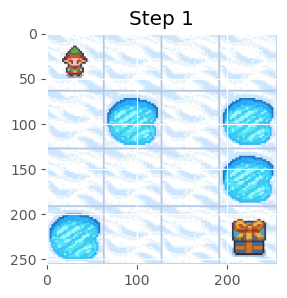

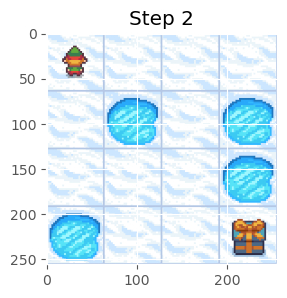

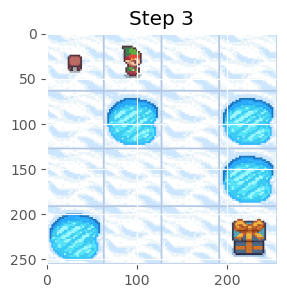

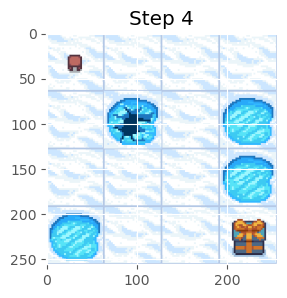

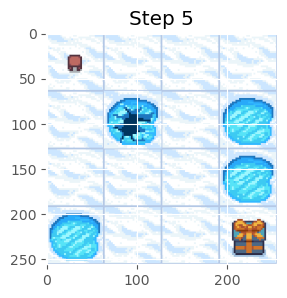

In [36]:
env = gym.make("FrozenLakeNotSlippery-v0", render_mode="rgb_array")
state , info = env.reset()

for i in range(5):
    frame = env.render()
    action = env.action_space.sample()
    new_state , reward, terminated, truncated, info = env.step(action)
    state = new_state
    

    plt.figure(figsize=(5, 3))
    plt.imshow(frame)
    plt.title(f"Step {i+1}")
    plt.show()

env.close()   

In [37]:
env = gym.make("FrozenLakeNotSlippery-v0", render_mode = "ansi")
state , info = env.reset()
states = []
for _ in range(5):
    print(env.render()) # ← print the returned string
    action = env.action_space.sample()
    new_state , reward, terminated, truncated, info = env.step(action)
    state = new_state
    states.append(state)

env.close() 


SFFF
FHFH
FFFH
HFFG

  (Right)
SFFF
FHFH
FFFH
HFFG

  (Down)
SFFF
FHFH
FFFH
HFFG

  (Up)
SFFF
FHFH
FFFH
HFFG

  (Left)
SFFF
FHFH
FFFH
HFFG



In [38]:
print(states) # 0: Left , 1:Down , 2: Right , 3:Up

[1, 5, 5, 5, 5]


### Manually Play the Environment

**OPTIONAL: Not visually pleasing to see a list, let's clear the output of the cell before writing the new state. For Jupyter Notebook users use the code shown in the cell below, for .py script use:**

    import os
    os.system('cls')

In [39]:
from IPython.display import clear_output

In [40]:
for letter in ['a','b','c']:
    print(letter)
    time.sleep(2)
    clear_output(wait=False)

In [41]:
for letter in ['a','b','c']:
    print(letter)
    time.sleep(2)
    clear_output(wait=True)

c


In [42]:
env = gym.make("FrozenLakeNotSlippery-v0")  # Load FrozenLake
observation , info = env.reset()  # Reset to initial state
for epsiode in range(4):
    print(observation)
    env.render()  # Render on the screen
    time.sleep(0.2)
    #clear_output(wait=True)
    action = env.action_space.sample()  # chose a random action
    observation , reward , terminated , truncated , info = env.step(action)  # Perform random action on the environment
    print(f"obs:{observation}, reward: {reward} , terminated: {int(terminated)} , truncated:{int(truncated)}")
env.close()  # dont forget to close the environment

0
obs:0, reward: 0 , terminated: 0 , truncated:0
0
obs:0, reward: 0 , terminated: 0 , truncated:0
0
obs:1, reward: 0 , terminated: 0 , truncated:0
1
obs:1, reward: 0 , terminated: 0 , truncated:0


In [43]:
env = gym.make("FrozenLakeNotSlippery-v0")  # Load FrozenLake
observation , info = env.reset()  # Reset to initial state
for epsiode in range(4):
    print(f"observation:{observation}")
    env.render()  # Render on the screen
    time.sleep(0.2)
    #clear_output(wait=True)
    action = env.action_space.sample()  # chose a random action
    observation, reward, terminared , truncated, info = env.step(action)  # Perform random action on the environment
    
env.close()  # dont forget to close the environment

observation:0
observation:4
observation:5
observation:5


In [44]:
env = gym.make("FrozenLakeNotSlippery-v0")  # Load FrozenLake
observation , info = env.reset()  # Reset to initial state
for epsiode in range(4):
    print(f"observation:{observation}")
    env.render()  # Render on the screen
    time.sleep(0.2)
    clear_output(wait=True)
    action = env.action_space.sample()  # chose a random action
    observation, reward, terminared , truncated, info = env.step(action)  # Perform random action on the environment
    
env.close()  # dont forget to close the environment

observation:5


In [45]:
env = gym.make("FrozenLakeNotSlippery-v0", render_mode = "ansi")  # Load FrozenLake
observation , info = env.reset()  # Reset to initial state
for epsiode in range(4):
    print(observation)
    print(env.render())  # Render on the screen
    time.sleep(0.2)
    clear_output(wait=True)
    action = env.action_space.sample()  # chose a random action
    observation, reward, terminated , truncated, info = env.step(action)  # Perform random action on the environment
    
env.close()  # dont forget to close the environment

5
  (Right)
SFFF
FHFH
FFFH
HFFG



Let us take a look at the possible actions.
You can find them here: https://github.com/openai/gym/blob/master/gym/envs/toy_text/frozen_lake.py

As we can see, there is just 1 observation, a single digit representing the current location, for a 4by4 "lake":

    0    1   2  3
    4    5   6  7
    8    9  10  11
    12  13  14  15

and four actions:

    LEFT = 0
    DOWN = 1
    RIGHT = 2
    UP = 3

The next cell contains code to play the game manually - Feel free to try it out by using the left and right arrow key.

### Very simple code to manually play. This will break if you don't use asdw() function correctly.

In [46]:
def asdw():
    '''
    This function gets the key press for gym action choice
    '''
    k = input()
    if k == 'a':
        action = 0
    if k == 's':
        action = 1
    if k == 'd':
        action = 2
    if k == 'w':
        action = 3
        
    return action

In [47]:
# env = gym.make("FrozenLakeNotSlippery-v0" , render_mode = "human")  # Load FrozenLake
# observation , info = env.reset()  # Reset to initial state
# for _ in range(10):
#     env.render()  # Render on the screen
#     clear_output(wait=True)
#     action = asdw()  # chose an action
#     observation, reward, terminated , truncated, info = env.step(action)  # Perform random action on the environment
    
#     if done:
#         print("Game Done")
#         break
# env.close()  # dont forget to close the environment

------------
--------------


# PART 2: 
# Creating the Q-Learning Table

Now that we validated the functionality of our function it is time to move on with the Q-Learning algorithm. 

Recall our Table is essentially a mapping of all possible state,action pairs and the expected reward for taking an action at a particular state that we will keep updating.


$$Q(s_t,a_t)$$

For our simple discrete Frozen Lake problem, this means we have 4 actions for columns, and 16 possible states (player location on the 4 by 4 grid). So our table will look like:

<table style="width:100%">
  <tr>
      <th></th>
    <th>A0 - LEFT</th>
    <th>A1 - DOWN</th>
    <th>A2 - RIGHT</th>
    <th>A3 - UP</th>
  </tr>
  <tr>
    <td><strong>State 0</strong></td>
    <td>Q(s,a)</td>
    <td>Q(s,a)</td>
      <td>Q(s,a)</td>
      <td>Q(s,a)</td>
  </tr>
  <tr>
      <td><strong>State 1</strong></td>
    <td>Q(s,a)</td>
    <td>Q(s,a)</td>
    <td>Q(s,a)</td>
      <td>Q(s,a)</td>
  </tr>
    <tr>
      <td><strong>State ...</strong></td>
    <td>...</td>
    <td>...</td>
    <td>...</td>
        <td>...</td>
  </tr>
    <tr>
      <td><strong>State 15</strong></td>
    <td>Q(s,a)</td>
    <td>Q(s,a)</td>
    <td>Q(s,a)</td>
        <td>Q(s,a)</td>
  </tr>
</table>

In [48]:
action_size = env.action_space.n
state_size = env.observation_space.n

In [49]:
print(f"action_size: {action_size},\nstate_size:{state_size}")

action_size: 4,
state_size:16


## Initial Q-Table

In [50]:
# Start with very small values for all our Q(s,a)
q_table = np.zeros([state_size, action_size])
q_table

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [51]:
q_table.shape

(16, 4)

# PART 3:
# Hyperparameters

**The Q-Learning update functions will require hyperparameters. we'll define them here. Often the best place to choose a good starting value is reading publications or through experimentation. Unfortunately, its very difficult to give general advice, as most environments are radically different to each other, and often hyperparameter tuning is required.**

**Q-Learning Equation Parameters: https://en.wikipedia.org/wiki/Q-learning**

In [60]:
# It is common to leave Hyperparameters in ALL CAPS to easily locate them
EPOCHS=5  # number of epochs/episodes to train for
ALPHA = 0.8 # aka the learning rate
GAMMA = 0.95 # aka the discount rate
# MAX_EPISODES = 100  # optional, also defined in env setup above

**Exploration vs. Exploitation Parameters**

Basically how fast do we reduce epsilon. Reduce too fast, agent won't have enough time to learn. Reduce too slow, you're wasting time picking random actions. Key here is that these value help balance exploration (random choice) versus explotation (always picking what works for that Q(s,a). It's a tough balance!

In [61]:
# Exploration vs. Exploitation parameters
epsilon = 1.0                 # Exploration rate: it explains the exploration rate. when it is 1, it means that the agent is muximally curious to pick a random step.
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability 
decay_rate = 0.001             # Exponential decay rate for exploration prob

# PART 4:
# Q-Table Update Functions Methodology

## Theoretical Background

### 1. The Goal: Maximize the Discounted Return

In reinforcement learning, an agent interacts with an environment over time, receiving rewards $R_t$ at each step. The agent's objective is to maximize the **discounted return**:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

Each future reward is multiplied by $\gamma^k$, where $k$ is how many steps ahead it occurs. This is a **geometric series** that converges (stays finite) as long as $0 \le \gamma < 1$.

### 2. The Discount Factor $\gamma$ (GAMMA)

| $\gamma$ value | Behaviour | Pizza analogy |
|---|---|---|
| $\gamma = 0$ | **Myopic** — only cares about the *immediate* reward | "I only care about the first bite" |
| $\gamma \to 1$ | **Far-sighted** — values future rewards almost equally | "I care about the whole meal, not just the first slice" |
| $0 < \gamma < 1$ | **Balanced** — future rewards matter but are discounted | "I care about the whole pizza, but the first slice matters a bit more" |

**Why discount?**
- **Mathematical**: ensures the infinite sum converges to a finite value ($\le R_{\max}/(1-\gamma)$)
- **Uncertainty**: the further in the future, the less certain the reward is
- **Preference**: a reward *now* is generally more valuable than the same reward *later*

### 3. The Bellman Equation → Q-Learning Update

The **Bellman optimality equation** for the Q-function states:

$$Q^*(s, a) = \mathbb{E}\!\left[r + \gamma \max_{a'} Q^*(s', a')\right]$$

In practice, we don't know $Q^*$, so we **estimate** it and update it iteratively using the **temporal-difference (TD) error**:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{TD target (new estimate)}} - \underbrace{Q(s,a)}_{\text{old estimate}}\Big]$$

This is exactly what the code does.   

-----

## Now it is time to dive into the training / Q-Table update methodology.<br />
First we will define some functions needed for training phase

* epsilon_greedy_action_selection: Is used to implement the epsilon greedy action selection routine.
* compute_next_q_value: Computes the next Q-Values according to the formula from the lecture
* reduce_epsilon: Reduces the $\epsilon$ used for the epsilon greedy algorithm

| Code Concept | Pizza Analogy |
| :--- | :--- |
| `q_table[discrete_state]` | Your mental list of how much you like each pizza based on past experience |
| `np.argmax(state_row)` | Picking the pizza with the highest rating on your list |
| `env.action_space.sample()` | Closing your eyes and pointing at a random pizza on the menu |
| `random_number > epsilon` | Flipping a weighted coin to decide: "Am I feeling adventurous today?" |
| `epsilon` | How often you allow yourself to be adventurous |

**FUNCTION TO SELECT AN ACTION**

If we simply always select the argmax() qtable value during training, we'll most likely get stuck in an explotation loop, so we'll use a random value to randomly select an action from time to time, helping the model explore , rather than exploit.

In [62]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    '''
    Pick a pizza. 90% of the time order your favourite,
    10% of the time try a random one.
    '''
    random_number = np.random.random()  # roll the dice

    # EXPLOITATION: order the pizza I already rate highest
    if random_number > epsilon:
        # My rating sheet for THIS specific situation (e.g. "feeling hungry")
        state_row = q_table[discrete_state, :]
        # Pick the pizza with the best rating (0=pepperoni, 1=margherita, ...)
        action = np.argmax(state_row)

    # EXPLORATION: ignore your ratings, grab a random pizza
    else:
        # Random pick: 0, 1, 2, or 3
        action = env.action_space.sample()

    return action   

In [63]:
# def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
#     '''
#     Returns an action for the agent. Note how it uses a random number to decide on
#     exploration versus explotation trade-off.
#     '''
#     random_number = np.random.random()
    
#     # EXPLOITATION, USE BEST Q(s,a) Value
#     if random_number > epsilon:
#         # Action row for a particular state
#         state_row = q_table[discrete_state,:]
#         # Index of highest action for state
#         # Recall action is mapped to index (e.g. 0=LEFT, 1=DOWN, etc..)
#         action = np.argmax(state_row)
    
#     # EXPLORATION, USE A RANDOM ACTION
#     else:
#         # Return a random 0,1,2,3 action
#         action = env.action_space.sample()
        
#     return action

**FUNCTION FOR Q_VALUE COMPUTATION**

**Here we have our main Q-Learning update equation, note how it takes in the old q-value, the next optimal q value, along with our current reward, and then updates the next q value accordingly.**



In [64]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    return old_q_value +  ALPHA * (reward + GAMMA * next_optimal_q_value - old_q_value)

|Code|Formula|Meaning|
|---|---|---|
|old_q_value|Q(s,a)|Your current estimate of how good this pizza is.|
|reward|$r$|The immediate "yum" you just felt.|
|GAMMA|$\gamma$|How much you trust future "yum"s|
|next_optimal_q_value|$max_{a'}Q(s′,a′)$|Best expected future rating from the next state.|
|ALPHA|$\alpha$|How much you trust this new info vs. your old belief.|
|reward + GAMMA * next_optimal_q_value|$r+(\gamma\times max_{a′}Q(s′,a′))$|TD target — your new "true" estimate|
|(...) - old_q_value|TD error|Surprise: how wrong your old estimate was|

**FUNCTION TO REDUCE EPSILON**

**As training continues, we need to balance explotation versus exploration, we want ot make sure our agent doesn't get trapped in a cycle going from an F square to another F Square back and forth. We also don't want our agent permanently choosing random values. We'll use the function below to try to balance this.**

Pizza analogy

When we first start visiting a pizza shop, we try everything (ε ≈ 1.0). After a few hundred visits, we've got a good sense of what's good, so we mostly order out favourites but still leave a small chance to try something new (ε ≈ 0.05). We never hit ε = 0 because we want to keep a tiny window open in case the menu changes.

In [65]:
def reduce_epsilon(epsilon,epoch):
    return min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*epoch)

----------
---------

# PART 5:
# Training of Agent and Updating Q-Table

If you plan on plotting your training progress, make sure to put this all in the same cell, otherwise matplotlib may not connect to the training loop and just show an empty plot.

In [66]:
# Reset just in case, watch lecture on this.
q_table = np.zeros([state_size, action_size])
total_reward = 0
epsilon = 1

In [67]:
EPOCHS

5

In [69]:
# List of rewards
rewards = []

# Play 20k games
for episode in range(EPOCHS):
    # Reset the environment
    state , info = env.reset()
    done = False
    total_rewards = 0
    
    while not done:
        action = epsilon_greedy_action_selection(epsilon,q_table, state)

        # Take the action (a) and observe the outcome state(s') and reward (r)
        new_state, reward, truncated , terminated , info = env.step(action)

        # Look up current/old qtable value Q(s_t,a_t)
        old_q_value =  q_table[state,action]  

        # Get the next optimal Q-Value
        next_optimal_q_value = np.max(q_table[new_state, :])  

        # Compute next q value
        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)   

        # Update Q Table
        q_table[state,action] = next_q

        total_rewards = total_rewards + reward
        
        # Our new state is state
        state = new_state

        
    episode += 1
    # Reduce epsilon (because we need less and less exploration)
    epsilon = reduce_epsilon(epsilon,episode) 
    rewards.append(total_rewards)


env.close()

In [ ]:
plt.plot(range(EPOCHS),np.cumsum(rewards))

In [ ]:
q_table

------------
-----------
# OPTIONAL

## Training with Active Visualization

**Optional if you want to "watch" the training happen. Note, this REALLY slows down training time since it visualizes each game, and we make it play 20k games.**

In [95]:
# Reset just in case, watch lecture on this.
q_table = np.zeros([state_size, action_size])
total_reward = 0
epsilon = 1

In [ ]:
##############################################
### VISUALIZATION OF TRAINING PROGRESS ######
#############################################
fig = plt.figure()
ax = fig.add_subplot(111)
plt.ion()
fig.canvas.draw()
log_interval = 1000 # Plot a new point every log_interval games, do NOT make this too small!
epoch_plot_tracker = []
total_reward_plot_tracker = []


###############################################
################################################
for episode in range(EPOCHS):
    # Reset the environment
    state , info = env.reset()
    done = False
    total_rewards = 0
    
    while not done:
        action = epsilon_greedy_action_selection(epsilon,q_table, state)

        # Take the action (a) and observe the outcome state(s') and reward (r)
        new_state, reward, truncated , terminated , info = env.step(action)

        
        # Look up current/old qtable value Q(s_t,a_t)
        old_q_value =  q_table[state,action]  

        # Get the next optimal Q-Value
        next_optimal_q_value = np.max(q_table[new_state, :])  

        # Compute next q value
        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)   

        # Update Q Table
        q_table[state,action] = next_q
        
        # Our new state is state
        state = new_state
        
        
          #### Use Ctrl+/ to uncomment this block all at once.
#         ########################################################################
#         ########## OPTIONAL TABLE REPORTING AND DISPLAY #######################
#         ######################################################################
#         print(f"Epsilon is currently {epsilon}")
#         print(f"Currently on Epoch {epoch}, total reward earned so far is {total_reward}")
#         print(f"Current state {state} and performing action {action}")
#         env.render()
#         print(q_table)
        
#         time.sleep(0.01)
#         clear_output(wait=True)
        
#         ######################################################################
#         ######################################################################
#         ######################################################################

        
    episode += 1
    # Reduce epsilon (because we need less and less exploration)
    epsilon = reduce_epsilon(epsilon,episode) 
    
    total_reward += reward # Since +1 is only time reward is recorded, meaning game is also done
    total_reward_plot_tracker.append(total_reward)
    epoch_plot_tracker.append(episode)
    
    ################ Plot the points and running mean ##################
    if episode % log_interval == 0:
        ax.clear() 
        ax.plot(epoch_plot_tracker,total_reward_plot_tracker) 
        fig.canvas.draw()

  ######################################################################
        


env.close()

--------
---------

# PART 5:
# Using Learned Q Table Results

Now it is time for a final evaluation round!
Let's see how well our first RL agent performs

In [100]:
state = env.reset()
rewards = 0
for _ in range(100):
    env.render()
    
    action = np.argmax(q_table[state])  # and chose action from the Q-Table
    state, reward,truncated , terminated , info = env.step(action) # Finally perform the action

    time.sleep(1)
    clear_output(wait=True)
    
    if done:
        break

env.close()

  (Right)
SFFF
FHFH
FFFH
HFFG
